# Banco de trabajo: interpretabilidad ResNet18 + KAN

Flujo para modelos híbridos ya entrenados (por ejemplo en `07_`).

**Objetivos**
1. Cargar checkpoint del modelo híbrido registrado en `reports/models/`.
2. Evaluar en validación y test.
3. Forward con cache de activaciones para analizar splines internos de la KAN.
4. Selección tipo **Sproud** de splines relevantes.
5. Ajuste simbólico sobre splines destacados.
6. Gráficos de splines (véase también `scripts/kan_plot_utils.py`).
7. **Integrated Gradients** (Captum) en imagen y en espacio latente.
8. Cruzar dimensiones latentes, splines e IG.

**Nota:** las rutas por defecto suelen apuntar al modelo híbrido entrenado en el notebook `07_`.


In [17]:
# Captum (IG), pykan, matplotlib: añade `scripts/` al path para importar `kan_plot_utils` si aplica.
from pathlib import Path
import sys
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, f1_score, confusion_matrix, classification_report

from captum.attr import IntegratedGradients, LayerIntegratedGradients

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from kan import KAN
from scripts.kan_plot_utils import estimate_kan_plot_load, plot_kan_edges_light

warnings.filterwarnings('ignore', message='std\(\): degrees of freedom is <= 0')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)


<>:30: SyntaxWarning: invalid escape sequence '\('
<>:30: SyntaxWarning: invalid escape sequence '\('
C:\Users\santy\AppData\Local\Temp\ipykernel_2316\2711250328.py:30: SyntaxWarning: invalid escape sequence '\('
  warnings.filterwarnings('ignore', message='std\(\): degrees of freedom is <= 0')


In [18]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cpu')
print('DEVICE:', DEVICE)

TRAIN_CSV = ROOT / 'src/data/processed/manifest_train.csv'
TEST_CSV = ROOT / 'src/data/processed/manifest_test.csv'
BACKBONE_FOR_KAN_HEAD = ROOT / 'reports/models/resnet18_tuned_best.pt'

MODEL_REGISTRY = {
    'hybrid_gap32': ROOT / 'reports/models/resnet18_kan_hybrid_gap32.pt',
    'end2end_singlephase': ROOT / 'reports/models/resnet18_kan_end2end_singlephase.pt',
    'kan_head_embeddings': ROOT / 'reports/models/kan_head_embeddings.pt',
    'kan_head_tuned_feats': ROOT / 'reports/models/kan_head_tuned_feats.pt',
}
MODEL_KEY = 'hybrid_gap32'
MODEL_PATH = MODEL_REGISTRY[MODEL_KEY]

IMG_SIZE = 224 if MODEL_KEY == 'hybrid_gap32' else 128
BATCH_SIZE = 4
CACHE_SAMPLES = 64
SPROUD_LAYER = 0
SPROUD_TOP_K = 12
SYMBOLIC_TOP_K = 6
SYMBOLIC_CANDIDATES = 3
SYMBOLIC_R2_THRESHOLD = 0.90
IG_N_STEPS = 24
IG_SAMPLE_STRATEGY = 'highest_malignant_prob'  # 'highest_malignant_prob' | 'first_malignant' | 'first'

print('Model path exists:', MODEL_PATH.exists())
print('Backbone for KAN head exists:', BACKBONE_FOR_KAN_HEAD.exists())
print('Model key:', MODEL_KEY)
print('Image size:', IMG_SIZE)


DEVICE: cpu
Model path exists: True
Backbone for KAN head exists: True
Model key: hybrid_gap32
Image size: 224


In [19]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

patients = train_df['patient_id'].dropna().unique()
train_pat, val_pat = train_test_split(patients, test_size=0.2, random_state=SEED)
tr_df = train_df[train_df['patient_id'].isin(train_pat)].copy()
val_df = train_df[train_df['patient_id'].isin(val_pat)].copy()

print('Train:', tr_df.shape, tr_df['label_name'].value_counts().to_dict())
print('Val:', val_df.shape, val_df['label_name'].value_counts().to_dict())
print('Test:', test_df.shape, test_df['label_name'].value_counts().to_dict())


Train: (2315, 10) {'BENIGN': 1383, 'MALIGNANT': 932}
Val: (549, 10) {'BENIGN': 300, 'MALIGNANT': 249}
Test: (422, 10) {'BENIGN': 248, 'MALIGNANT': 174}


In [20]:
class MammographyDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['image_path_local']).convert('RGB')
        x = self.transform(image)
        y = int(row['label'])
        return x, y, row['image_path_local']


def build_eval_transform(img_size=IMG_SIZE):
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])


eval_tfms = build_eval_transform()
val_loader = DataLoader(MammographyDataset(val_df, eval_tfms), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(MammographyDataset(test_df, eval_tfms), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


In [21]:
def load_tuned_resnet18_backbone(backbone_path: Path):
    full = models.resnet18(weights=None)
    full.fc = nn.Linear(full.fc.in_features, 2)
    full.load_state_dict(torch.load(backbone_path, map_location=DEVICE))
    features = nn.Sequential(*list(full.children())[:-1])
    return features


def infer_checkpoint_family(state_dict):
    keys = list(state_dict.keys())
    if any(k.startswith('stem.') or k.startswith('kan.') for k in keys):
        return 'end2end'
    if any(k.startswith('act_fun.') or k.startswith('symbolic_fun.') for k in keys):
        return 'kan_head'
    raise ValueError('Checkpoint no reconocido. Revisa las keys del state_dict.')


def extract_kan_state_dict(state_dict):
    if any(k.startswith('kan.') for k in state_dict.keys()):
        return {k[len('kan.'):]: v for k, v in state_dict.items() if k.startswith('kan.')}
    return state_dict


def infer_kan_hparams_from_state(kan_state):
    layer_ids = sorted({int(k.split('.')[1]) for k in kan_state if k.startswith('act_fun.') and k.endswith('.grid')})
    width = [int(kan_state[f'act_fun.{layer_ids[0]}.grid'].shape[0])]
    for layer_id in layer_ids:
        coef_shape = kan_state[f'act_fun.{layer_id}.coef'].shape
        width.append(int(coef_shape[1]))
    grid_points = int(kan_state['act_fun.0.grid'].shape[1])
    coef_points = int(kan_state['act_fun.0.coef'].shape[2])
    k = grid_points - coef_points - 1
    grid = coef_points - k
    return {
        'width': width,
        'grid': grid,
        'k': k,
    }


class ResNetKAN(nn.Module):
    def __init__(self, kan_width=None, kan_grid=3, kan_k=3):
        super().__init__()
        if kan_width is None:
            kan_width = [64, 8, 2]
        base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.stem = nn.Sequential(base.conv1, base.bn1, base.relu, base.maxpool)
        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.layer4 = base.layer4
        self.avgpool = base.avgpool
        
        bottleneck_dim = kan_width[0]
        self.bottleneck = nn.Sequential(
            nn.Linear(512, bottleneck_dim),
            nn.GELU(),
        )
        self.kan = KAN(width=kan_width, grid=kan_grid, k=kan_k, auto_save=False, seed=SEED)

    def forward_features(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        z = self.avgpool(x).flatten(1)
        z = self.bottleneck(z)
        return z

    def forward(self, x):
        z = self.forward_features(x)
        logits = self.kan(z)
        return logits


class ResNetKANHeadWrapper(nn.Module):
    def __init__(self, backbone_path: Path, kan_width, kan_grid, kan_k):
        super().__init__()
        self.features = load_tuned_resnet18_backbone(backbone_path)
        self.kan = KAN(width=kan_width, grid=kan_grid, k=kan_k, auto_save=False, seed=SEED)

    def forward_features(self, x):
        return self.features(x).flatten(1)

    def forward(self, x):
        z = self.forward_features(x)
        logits = self.kan(z)
        return logits


state = torch.load(MODEL_PATH, map_location=DEVICE)
checkpoint_family = infer_checkpoint_family(state)
kan_state = extract_kan_state_dict(state)
kan_hparams = infer_kan_hparams_from_state(kan_state)
print('Checkpoint family:', checkpoint_family)
print('KAN hparams inferred:', kan_hparams)

if checkpoint_family == 'end2end':
    model = ResNetKAN(
        kan_width=kan_hparams['width'],
        kan_grid=kan_hparams['grid'],
        kan_k=kan_hparams['k'],
    ).to(DEVICE)
    model.load_state_dict(state)
else:
    model = ResNetKANHeadWrapper(
        backbone_path=BACKBONE_FOR_KAN_HEAD,
        kan_width=kan_hparams['width'],
        kan_grid=kan_hparams['grid'],
        kan_k=kan_hparams['k'],
    ).to(DEVICE)
    model.kan.load_state_dict(kan_state)

model.eval()

    # PyKAN >= 0.2.x: usa kan.get_act(x) para cachear activaciones
if hasattr(model.kan, 'auto_save'):
    model.kan.auto_save = False

print('Loaded:', MODEL_PATH)
model


Checkpoint family: end2end
KAN hparams inferred: {'width': [64, 8, 2], 'grid': 3, 'k': 3}
Loaded: G:\Cosas_programacion\Breast Cancer Interpretable-ml\reports\models\resnet18_kan_hybrid_gap32.pt


ResNetKAN(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu):

In [22]:
def evaluate(loader):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    total_seen = 0
    y_true, y_pred, y_prob, paths = [], [], [], []

    with torch.no_grad():
        for x, y, batch_paths in loader:
            if x.size(0) < 2:
                continue
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            logits = model(x)
            loss = criterion(logits, y)
            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = logits.argmax(1)

            batch_size = y.size(0)
            total_loss += loss.item() * batch_size
            total_seen += batch_size
            y_true.extend(y.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())
            y_prob.extend(probs.cpu().numpy().tolist())
            paths.extend(batch_paths)

    metrics = {
        'loss': total_loss / total_seen,
        'acc': accuracy_score(y_true, y_pred),
        'auc': roc_auc_score(y_true, y_prob),
        'recall_malignant': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_malignant': f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }
    return metrics, np.array(y_true), np.array(y_pred), np.array(y_prob), np.array(paths)


val_metrics, y_val, yhat_val, p_val, paths_val = evaluate(val_loader)
test_metrics, y_test, yhat_test, p_test, paths_test = evaluate(test_loader)

print('Val metrics:', val_metrics)
print('Test metrics:', test_metrics)
print('Test confusion matrix:')
print(confusion_matrix(y_test, yhat_test))
print(classification_report(y_test, yhat_test, target_names=['BENIGN', 'MALIGNANT']))


Val metrics: {'loss': 0.6378862511937635, 'acc': 0.6405109489051095, 'auc': 0.6804771505376345, 'recall_malignant': 0.6693548387096774, 'f1_malignant': 0.6275992438563327}
Test metrics: {'loss': 0.6653068499260039, 'acc': 0.5781990521327014, 'auc': 0.6353355580274379, 'recall_malignant': 0.6379310344827587, 'f1_malignant': 0.555}
Test confusion matrix:
[[133 115]
 [ 63 111]]
              precision    recall  f1-score   support

      BENIGN       0.68      0.54      0.60       248
   MALIGNANT       0.49      0.64      0.56       174

    accuracy                           0.58       422
   macro avg       0.58      0.59      0.58       422
weighted avg       0.60      0.58      0.58       422



### Como leer esta evaluacion

- `Val metrics` resume el rendimiento en validacion; `Test metrics` hace lo mismo en test.
- `loss`: error medio de clasificacion. Menor es mejor.
- `acc`: proporcion total de aciertos.
- `auc`: capacidad del modelo para separar benigno y maligno usando probabilidades. Mas cerca de 1 es mejor.
- `recall_malignant`: fraccion de casos malignos detectados correctamente. En contexto medico suele ser una metrica critica.
- `f1_malignant`: equilibrio entre precision y recall para la clase maligna.
- `confusion matrix`: muestra cuantos casos de cada clase fueron clasificados correctamente o confundidos.
- `classification report`: detalle por clase de precision, recall y F1.


,layer,in_dim,out_dim,edges
0,0,64,8,512
1,1,8,2,16


Cached samples: 64
KAN acts[0] shape: (64, 64)
KAN spline_postacts[0] shape: (64, 8, 64)


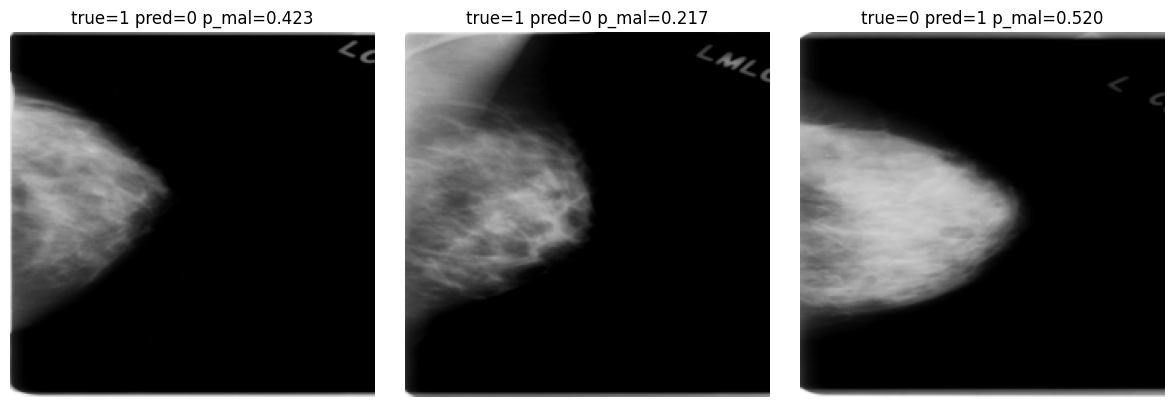

In [23]:
def collect_eval_subset(loader, max_samples=CACHE_SAMPLES):
    xs, ys, zs, probs, preds, paths = [], [], [], [], [], []
    with torch.no_grad():
        for x, y, batch_paths in loader:
            if x.size(0) < 2:
                continue
            x = x.to(DEVICE)
            logits = model(x)
            prob = torch.softmax(logits, dim=1)[:, 1]
            pred = logits.argmax(1)
            z = model.forward_features(x)

            xs.append(x.cpu())
            ys.append(y.cpu())
            zs.append(z.cpu())
            probs.append(prob.cpu())
            preds.append(pred.cpu())
            paths.extend(batch_paths)

            if sum(t.size(0) for t in xs) >= max_samples:
                break

    X = torch.cat(xs, dim=0)[:max_samples]
    Y = torch.cat(ys, dim=0)[:max_samples]
    Z = torch.cat(zs, dim=0)[:max_samples]
    P = torch.cat(probs, dim=0)[:max_samples]
    H = torch.cat(preds, dim=0)[:max_samples]
    paths = paths[:max_samples]

    with torch.no_grad():
        _ = model.kan(Z.to(DEVICE))

    return X, Y, Z, P, H, paths


X_cache, y_cache, z_cache, p_cache, pred_cache, path_cache = collect_eval_subset(val_loader, max_samples=CACHE_SAMPLES)
plot_load = pd.DataFrame(estimate_kan_plot_load(model.kan))
display(plot_load)
print('Cached samples:', len(X_cache))
print('KAN acts[0] shape:', tuple(model.kan.acts[0].shape))
print('KAN spline_postacts[0] shape:', tuple(model.kan.spline_postacts[0].shape))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, image_t, y, pred, prob in zip(axes, X_cache[:3], y_cache[:3], pred_cache[:3], p_cache[:3]):
    img = image_t.permute(1, 2, 0).numpy()
    img = np.clip(img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)
    ax.imshow(img)
    ax.set_title(f'true={int(y)} pred={int(pred)} p_mal={float(prob):.3f}')
    ax.axis('off')
plt.tight_layout()
plt.show()


### Como leer esta tabla de cacheo

- `plot_load` estima cuantas conexiones tiene cada capa de la KAN y ayuda a anticipar el costo del plot.
- `layer`: capa de la KAN analizada.
- `in_dim`: numero de variables de entrada a esa capa.
- `out_dim`: numero de salidas de esa capa.
- `edges`: numero total de splines/aristas en la capa (`in_dim * out_dim`).
- `Cached samples` indica cuantas muestras reales se usaron para poblar `acts` y `spline_postacts`.


In [24]:
def sproud_importance(kan_model, layer=0):
    spline_postacts = kan_model.spline_postacts[layer]
    importance = spline_postacts.abs().mean(dim=0)  # [out, in]
    return importance


def sproud_select_edges(kan_model, layer=0, top_k=SPROUD_TOP_K):
    importance = sproud_importance(kan_model, layer=layer)
    out_dim, in_dim = importance.shape
    flat = importance.flatten()
    top_idx = torch.argsort(flat, descending=True)[:top_k]
    rows = []
    for rank, idx in enumerate(top_idx.tolist(), start=1):
        out_idx = idx // in_dim
        in_idx = idx % in_dim
        rows.append({
            'rank': rank,
            'layer': layer,
            'out_idx': int(out_idx),
            'in_idx': int(in_idx),
            'importance': float(importance[out_idx, in_idx].cpu()),
        })
    return importance, pd.DataFrame(rows)


importance_map, sproud_df = sproud_select_edges(model.kan, layer=SPROUD_LAYER, top_k=SPROUD_TOP_K)
sproud_df['latent_dim'] = sproud_df['in_idx']
sproud_df['class_logit'] = sproud_df['out_idx'].map({0: 'BENIGN_LOGIT', 1: 'MALIGNANT_LOGIT'})
display(sproud_df)
print('Unique latent dims selected by Sproud:', sproud_df['latent_dim'].nunique())


,rank,layer,out_idx,in_idx,importance,latent_dim,class_logit
0,1,0,6,9,0.281543,9,NaN
1,2,0,2,13,0.280689,13,NaN
2,3,0,3,9,0.252902,9,NaN
3,4,0,3,13,0.247614,13,NaN
4,5,0,0,57,0.244014,57,BENIGN_LOGIT
5,6,0,2,9,0.238556,9,NaN
6,7,0,6,63,0.235821,63,NaN
7,8,0,7,9,0.221666,9,NaN
8,9,0,4,23,0.217154,23,NaN
9,10,0,6,23,0.201653,23,NaN


Unique latent dims selected by Sproud: 6


### Como leer la tabla de Sproud

- Esta tabla ordena los splines mas importantes de la capa elegida.
- `rank`: posicion de importancia dentro del top seleccionado.
- `layer`: capa de la KAN donde vive el spline.
- `out_idx`: neurona/logit de salida al que llega el spline.
- `in_idx` / `latent_dim`: variable latente del backbone que alimenta ese spline.
- `importance`: importancia media del spline segun la magnitud absoluta de sus activaciones post-spline.
- `class_logit`: ayuda a interpretar si el spline empuja mas al logit benigno o maligno.


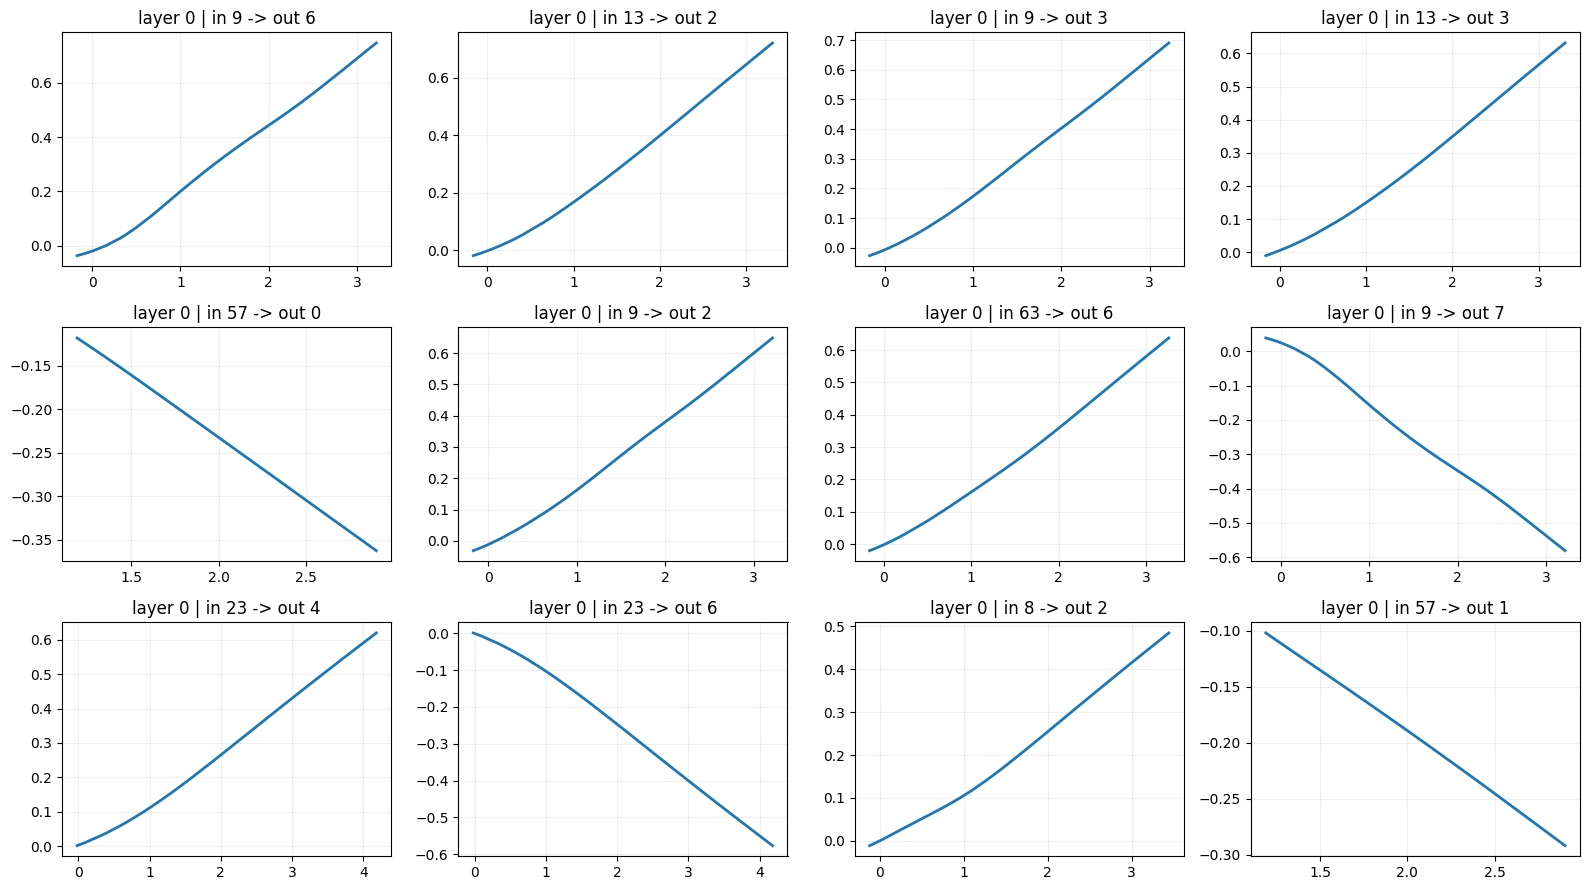

Pairs plotted (in_idx, out_idx): [(9, 6), (13, 2), (9, 3), (13, 3), (57, 0), (9, 2), (63, 6), (9, 7), (23, 4), (23, 6), (8, 2), (57, 1)]


In [25]:
# PyKAN >= 0.2.x: cachear activaciones antes de visualizar
model.kan.get_act(z_cache[:128].to(DEVICE))
fig, pairs = plot_kan_edges_light(
    model.kan,
    layer=SPROUD_LAYER,
    top_k=SPROUD_TOP_K,
    max_points=128,
    sample_points=False,
)
plt.show()
print('Pairs plotted (in_idx, out_idx):', pairs)


In [26]:
def symbolic_fit_for_edges(kan_model, edges_df, layer=0, topk=SYMBOLIC_CANDIDATES, r2_threshold=SYMBOLIC_R2_THRESHOLD):
    results = []
    for row in edges_df.head(SYMBOLIC_TOP_K).itertuples(index=False):
        in_idx = int(row.in_idx)
        out_idx = int(row.out_idx)
        before_name = kan_model.symbolic_fun[layer].funs_name[out_idx][in_idx]
        best_name, _, best_r2, best_c = kan_model.suggest_symbolic(layer, in_idx, out_idx, topk=topk, verbose=False)
        fixed = False
        if float(best_r2) >= r2_threshold:
            kan_model.fix_symbolic(layer, in_idx, out_idx, best_name, verbose=False, log_history=False)
            fixed = True
        after_name = kan_model.symbolic_fun[layer].funs_name[out_idx][in_idx]
        results.append({
            'layer': layer,
            'out_idx': out_idx,
            'in_idx': in_idx,
            'importance': float(row.importance),
            'before_name': before_name,
            'best_symbolic': best_name,
            'best_r2': float(best_r2),
            'complexity': float(best_c),
            'fixed': fixed,
            'after_name': after_name,
        })
    return pd.DataFrame(results)


symbolic_df = symbolic_fit_for_edges(model.kan, sproud_df, layer=SPROUD_LAYER)
display(symbolic_df)

latent_vars = [f'z_{i}' for i in range(model.kan.width_in[0])]
try:
    symbolic_formula = model.kan.symbolic_formula(var=latent_vars)
    print('symbolic_formula() ejecutada correctamente')
    print(symbolic_formula)
except Exception as e:
    symbolic_formula = None
    print('No se pudo obtener una formula simbolica global completa:', repr(e))
    print('La tabla symbolic_df contiene la formulacion simbolica local de los splines mas importantes.')


,layer,out_idx,in_idx,importance,before_name,best_symbolic,best_r2,complexity,fixed,after_name
0,0,6,9,0.281543,0,x,0.997270,1.0,True,x
1,0,2,13,0.280689,0,sin,0.999943,2.0,True,sin
2,0,3,9,0.252902,0,cos,0.999792,2.0,True,cos
3,0,3,13,0.247614,0,cos,0.999990,2.0,True,cos
4,0,0,57,0.244014,0,x,0.999971,1.0,True,x
5,0,2,9,0.238556,0,sin,0.999773,2.0,True,sin


symbolic_formula() ejecutada correctamente
([0, 0], [z_0, z_1, z_2, z_3, z_4, z_5, z_6, z_7, z_8, z_9, z_10, z_11, z_12, z_13, z_14, z_15, z_16, z_17, z_18, z_19, z_20, z_21, z_22, z_23, z_24, z_25, z_26, z_27, z_28, z_29, z_30, z_31, z_32, z_33, z_34, z_35, z_36, z_37, z_38, z_39, z_40, z_41, z_42, z_43, z_44, z_45, z_46, z_47, z_48, z_49, z_50, z_51, z_52, z_53, z_54, z_55, z_56, z_57, z_58, z_59, z_60, z_61, z_62, z_63])


### Como leer las tablas simbolicas iniciales

- `symbolic_df` resume el ajuste simbolico spline por spline sobre los edges mas importantes.
- `before_name`: funcion simbolica previa del spline antes del ajuste.
- `best_symbolic`: mejor funcion candidata encontrada para ese spline.
- `best_r2`: calidad del ajuste simbolico. Valores cercanos a 1 indican que la funcion simbolica explica muy bien el spline.
- `complexity`: complejidad relativa de la funcion elegida.
- `fixed`: indica si el spline fue fijado a esa funcion porque supero el umbral `r2_threshold`.
- `after_name`: nombre final de la funcion simbolica tras el ajuste.
- `symbolic_formula()`: intenta resumir toda la KAN en formulas sobre las variables latentes `z_i`.


,latent_dim,latent_value,latent_ig,latent_ig_abs,in_sproud,sproud_edges_count
0,17,-0.070256,0.115641,0.115641,False,0
1,34,1.342066,0.095354,0.095354,False,0
2,29,2.625316,0.068228,0.068228,False,0
3,39,2.765785,0.057410,0.057410,False,0
4,38,2.019389,0.043267,0.043267,False,0
5,45,3.569863,0.042371,0.042371,False,0
6,49,2.424731,0.033216,0.033216,False,0
7,41,3.149017,-0.028762,0.028762,False,0
8,63,-0.161386,0.022386,0.022386,True,1
9,46,1.913205,-0.019490,0.019490,False,0


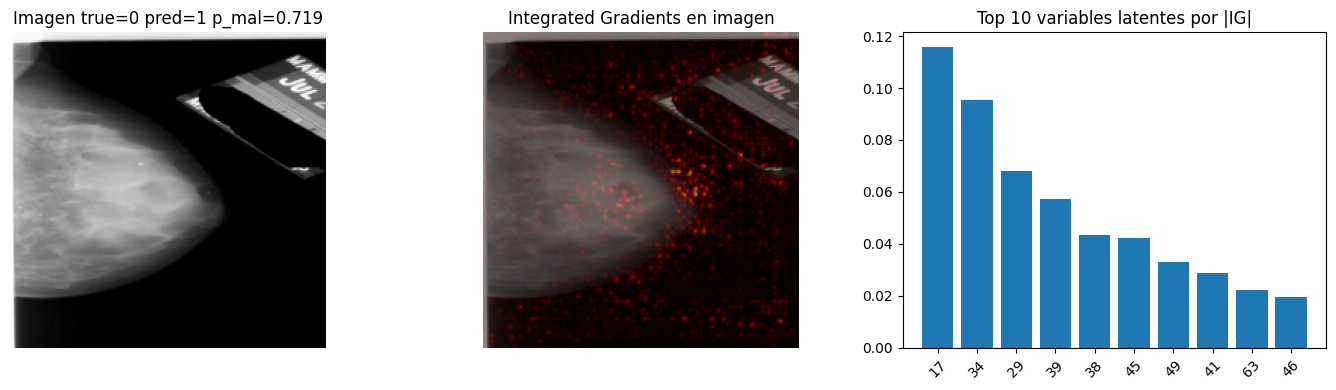

In [27]:
def select_ig_index(labels, probs, strategy=IG_SAMPLE_STRATEGY):
    labels = np.asarray(labels)
    probs = np.asarray(probs)
    if strategy == 'highest_malignant_prob':
        return int(np.argmax(probs))
    if strategy == 'first_malignant':
        malignant = np.where(labels == 1)[0]
        return int(malignant[0]) if len(malignant) else 0
    return 0


def normalize_map(x):
    x = x.astype(np.float32)
    x = np.abs(x)
    denom = x.max() if x.max() > 0 else 1.0
    return x / denom


ig_idx = select_ig_index(y_cache.numpy(), p_cache.numpy(), strategy=IG_SAMPLE_STRATEGY)
input_sample = X_cache[ig_idx:ig_idx + 1].to(DEVICE)
label_sample = int(y_cache[ig_idx])
prob_sample = float(p_cache[ig_idx])
pred_sample = int(pred_cache[ig_idx])
path_sample = path_cache[ig_idx]

if pred_sample == 1:
    target_class = 1
else:
    target_class = 0

ig = IntegratedGradients(lambda inp: model(inp)[:, target_class])
input_attr = ig.attribute(input_sample, baselines=torch.zeros_like(input_sample), n_steps=IG_N_STEPS)
input_attr_np = input_attr.detach().cpu().numpy()[0]
input_heatmap = normalize_map(np.max(np.abs(input_attr_np), axis=0))

lig = LayerIntegratedGradients(lambda inp: model(inp)[:, target_class], model.bottleneck)
latent_attr = lig.attribute(input_sample, baselines=torch.zeros_like(input_sample), n_steps=IG_N_STEPS)
latent_attr = latent_attr.detach().cpu().view(-1)
latent_values = model.forward_features(input_sample).detach().cpu().view(-1)

latent_ig_df = pd.DataFrame({
    'latent_dim': np.arange(len(latent_attr)),
    'latent_value': latent_values.numpy(),
    'latent_ig': latent_attr.numpy(),
    'latent_ig_abs': np.abs(latent_attr.numpy()),
})
latent_ig_df['in_sproud'] = latent_ig_df['latent_dim'].isin(sproud_df['latent_dim'])
latent_ig_df['sproud_edges_count'] = latent_ig_df['latent_dim'].map(sproud_df['latent_dim'].value_counts()).fillna(0).astype(int)
latent_ig_df = latent_ig_df.sort_values('latent_ig_abs', ascending=False).reset_index(drop=True)

display(latent_ig_df.head(15))

img = input_sample.detach().cpu()[0].permute(1, 2, 0).numpy()
img = np.clip(img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(img)
axes[0].set_title(f'Imagen true={label_sample} pred={pred_sample} p_mal={prob_sample:.3f}')
axes[0].axis('off')
axes[1].imshow(img)
axes[1].imshow(input_heatmap, cmap='hot', alpha=0.5)
axes[1].set_title('Integrated Gradients en imagen')
axes[1].axis('off')
axes[2].bar(latent_ig_df.head(10)['latent_dim'].astype(str), latent_ig_df.head(10)['latent_ig_abs'])
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_title('Top 10 variables latentes por |IG|')
plt.tight_layout()
plt.show()


### Como leer la tabla y los graficos de IG

- `latent_ig_df` ordena las variables latentes por importancia segun Layer Integrated Gradients.
- `latent_dim`: indice de la variable latente.
- `latent_value`: valor real de esa variable en la muestra analizada.
- `latent_ig`: atribucion con signo. Positivo empuja hacia la clase objetivo; negativo la frena.
- `latent_ig_abs`: magnitud absoluta de la atribucion. Sirve para ordenar importancia sin importar el signo.
- `in_sproud`: indica si esa variable tambien participa en splines destacados por Sproud.
- `sproud_edges_count`: numero de splines importantes donde reaparece esa variable.
- El heatmap sobre la imagen muestra que regiones del input contribuyeron mas a la prediccion.
- La barra de `Top 10 variables latentes por |IG|` muestra las dimensiones mas influyentes del embedding.


,latent_dim,latent_value,latent_ig,latent_ig_abs,in_sproud,sproud_edges_count,selected_by_sproud
0,17,-0.070256,0.115641,0.115641,False,0,False
1,34,1.342066,0.095354,0.095354,False,0,False
2,29,2.625316,0.068228,0.068228,False,0,False
3,39,2.765785,0.057410,0.057410,False,0,False
4,38,2.019389,0.043267,0.043267,False,0,False
5,45,3.569863,0.042371,0.042371,False,0,False
6,49,2.424731,0.033216,0.033216,False,0,False
7,41,3.149017,-0.028762,0.028762,False,0,False
8,63,-0.161386,0.022386,0.022386,True,1,True
9,46,1.913205,-0.019490,0.019490,False,0,False


,latent_dim,latent_value,latent_ig,latent_ig_abs,in_sproud,sproud_edges_count,selected_by_sproud
8,63,-0.161386,0.022386,0.022386,True,1,True
15,23,3.690795,0.009753,0.009753,True,2,True
16,8,-0.103878,0.008796,0.008796,True,1,True
19,57,2.684124,-0.004910,0.004910,True,2,True


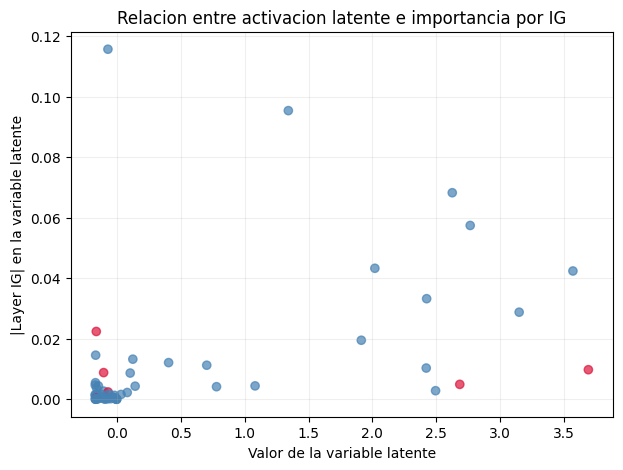

Latent dims seleccionadas por Sproud: [8, 9, 13, 23, 57, 63] ...
Interseccion entre top-20 por |IG| y Sproud: [63, 23, 8, 57]


In [28]:
sproud_latent_set = set(sproud_df['latent_dim'].tolist())
top_latent_ig = latent_ig_df.head(20).copy()
top_latent_ig['selected_by_sproud'] = top_latent_ig['latent_dim'].isin(sproud_latent_set)

overlap_df = top_latent_ig[top_latent_ig['selected_by_sproud']].copy()
display(top_latent_ig)
display(overlap_df)

relation_df = latent_ig_df.copy()
relation_df['selected_by_sproud'] = relation_df['latent_dim'].isin(sproud_latent_set)
relation_df['color'] = relation_df['selected_by_sproud'].map({True: 'crimson', False: 'steelblue'})

plt.figure(figsize=(7, 5))
plt.scatter(relation_df['latent_value'], relation_df['latent_ig_abs'], c=relation_df['color'], alpha=0.7)
plt.xlabel('Valor de la variable latente')
plt.ylabel('|Layer IG| en la variable latente')
plt.title('Relacion entre activacion latente e importancia por IG')
plt.grid(alpha=0.2)
plt.show()

print('Latent dims seleccionadas por Sproud:', sorted(list(sproud_latent_set))[:20], '...')
print('Interseccion entre top-20 por |IG| y Sproud:', overlap_df['latent_dim'].tolist())


### Como leer las tablas de interseccion Sproud vs IG

- `top_latent_ig` contiene las variables latentes mas influyentes segun IG.
- `selected_by_sproud` marca si una de esas variables tambien fue seleccionada por Sproud.
- `overlap_df` muestra la interseccion explicita entre ambos criterios.
- El scatter relaciona:
  - eje X: valor de la variable latente,
  - eje Y: importancia absoluta por IG,
  - color: si la variable tambien fue seleccionada por Sproud.
- Si una variable aparece fuerte tanto en Sproud como en IG, suele ser una candidata especialmente interesante para interpretacion.


Variables mas presentes en BENIGNO (menor presencia relativa en maligno):


,latent_dim,mean_benign,mean_malignant,mean_abs_benign,mean_abs_malignant,delta_malignant_minus_benign,delta_abs_malignant_minus_benign,sproud_edges_count,in_top20_ig,latent_ig,latent_ig_abs
0,13,1.649047,0.894824,1.665156,0.903359,-0.754223,-0.761797,2,False,0.000331,0.000331
1,9,1.450580,0.801558,1.478483,0.840712,-0.649022,-0.637771,4,False,-0.002397,0.002397
2,20,1.388506,0.772730,1.404590,0.780469,-0.615776,-0.624122,0,False,0.000130,0.000130
3,63,1.505866,0.915532,1.514615,0.929894,-0.590334,-0.584721,1,True,0.022386,0.022386
4,8,1.755823,1.168356,1.768900,1.168356,-0.587467,-0.600543,1,True,0.008796,0.008796
5,48,1.149660,0.621921,1.163464,0.652445,-0.527739,-0.511019,0,False,-0.000564,0.000564
6,17,1.350757,0.862627,1.358252,0.877063,-0.488130,-0.481189,0,True,0.115641,0.115641
7,58,0.701757,0.279711,0.728967,0.323300,-0.422047,-0.405667,0,True,0.014557,0.014557
8,24,1.270100,0.953639,1.294344,0.959629,-0.316462,-0.334715,0,False,0.001211,0.001211
9,12,0.166942,0.014413,0.257140,0.145884,-0.152529,-0.111256,0,False,0.000013,0.000013


Variables mas presentes en MALIGNO:


,latent_dim,mean_benign,mean_malignant,mean_abs_benign,mean_abs_malignant,delta_malignant_minus_benign,delta_abs_malignant_minus_benign,sproud_edges_count,in_top20_ig,latent_ig,latent_ig_abs
0,23,1.450896,2.116035,1.452510,2.116035,0.665139,0.663525,2,True,0.009753,0.009753
1,41,0.884521,1.541809,0.928717,1.541809,0.657288,0.613091,0,True,-0.028762,0.028762
2,39,0.892220,1.378748,0.893157,1.378748,0.486528,0.485591,0,True,0.057410,0.057410
3,46,0.365148,0.810885,0.420517,0.810885,0.445737,0.390368,0,True,-0.019490,0.019490
4,38,0.710867,1.133643,0.730118,1.133643,0.422775,0.403525,0,True,0.043267,0.043267
5,49,0.909075,1.261614,0.923665,1.261614,0.352539,0.337949,0,True,0.033216,0.033216
6,53,0.694900,1.028025,0.739300,1.028025,0.333126,0.288725,0,True,-0.010303,0.010303
7,62,0.581060,0.894993,0.637389,0.894993,0.313933,0.257603,0,False,-0.002818,0.002818
8,45,2.055138,2.312925,2.055138,2.312925,0.257787,0.257787,0,True,0.042371,0.042371
9,34,0.114830,0.325956,0.196687,0.354390,0.211126,0.157703,0,True,0.095354,0.095354


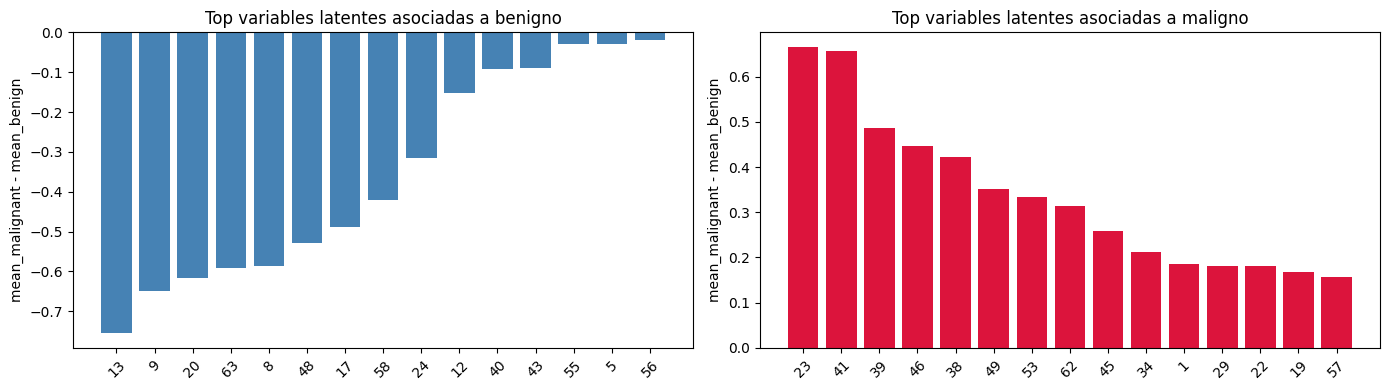

,latent_dim,mean_benign,mean_malignant,mean_abs_benign,mean_abs_malignant,delta_malignant_minus_benign,delta_abs_malignant_minus_benign,sproud_edges_count,in_top20_ig,latent_ig,latent_ig_abs,class_presence
6,17,1.350757,0.862627,1.358252,0.877063,-0.488130,-0.481189,0,True,0.115641,0.115641,BENIGN_MORE_PRESENT
3,63,1.505866,0.915532,1.514615,0.929894,-0.590334,-0.584721,1,True,0.022386,0.022386,BENIGN_MORE_PRESENT
7,58,0.701757,0.279711,0.728967,0.323300,-0.422047,-0.405667,0,True,0.014557,0.014557,BENIGN_MORE_PRESENT
4,8,1.755823,1.168356,1.768900,1.168356,-0.587467,-0.600543,1,True,0.008796,0.008796,BENIGN_MORE_PRESENT
14,56,-0.120687,-0.140737,0.125313,0.140737,-0.020050,0.015424,0,True,0.008650,0.008650,BENIGN_MORE_PRESENT
13,5,-0.018510,-0.046758,0.116515,0.120265,-0.028248,0.003750,0,True,0.005457,0.005457,BENIGN_MORE_PRESENT
11,43,-0.001764,-0.090970,0.113398,0.106151,-0.089206,-0.007246,0,False,0.004389,0.004389,BENIGN_MORE_PRESENT
1,9,1.450580,0.801558,1.478483,0.840712,-0.649022,-0.637771,4,False,-0.002397,0.002397,BENIGN_MORE_PRESENT
10,40,-0.027194,-0.118045,0.126805,0.133611,-0.090851,0.006806,0,False,-0.001580,0.001580,BENIGN_MORE_PRESENT
8,24,1.270100,0.953639,1.294344,0.959629,-0.316462,-0.334715,0,False,0.001211,0.001211,BENIGN_MORE_PRESENT


In [29]:
# Variables latentes mas presentes en benigno vs maligno
latent_by_class = pd.DataFrame({
    'latent_dim': np.arange(z_cache.shape[1]),
    'mean_benign': z_cache[y_cache == 0].mean(dim=0).cpu().numpy(),
    'mean_malignant': z_cache[y_cache == 1].mean(dim=0).cpu().numpy(),
    'mean_abs_benign': z_cache[y_cache == 0].abs().mean(dim=0).cpu().numpy(),
    'mean_abs_malignant': z_cache[y_cache == 1].abs().mean(dim=0).cpu().numpy(),
})
latent_by_class['delta_malignant_minus_benign'] = latent_by_class['mean_malignant'] - latent_by_class['mean_benign']
latent_by_class['delta_abs_malignant_minus_benign'] = latent_by_class['mean_abs_malignant'] - latent_by_class['mean_abs_benign']
latent_by_class['sproud_edges_count'] = latent_by_class['latent_dim'].map(sproud_df['latent_dim'].value_counts()).fillna(0).astype(int)
latent_by_class['in_top20_ig'] = latent_by_class['latent_dim'].isin(top_latent_ig['latent_dim'])
latent_by_class = latent_by_class.merge(
    latent_ig_df[['latent_dim', 'latent_ig', 'latent_ig_abs']],
    on='latent_dim',
    how='left',
)

most_benign = latent_by_class.sort_values('delta_malignant_minus_benign', ascending=True).head(15).reset_index(drop=True)
most_malignant = latent_by_class.sort_values('delta_malignant_minus_benign', ascending=False).head(15).reset_index(drop=True)

print('Variables mas presentes en BENIGNO (menor presencia relativa en maligno):')
display(most_benign)
print('Variables mas presentes en MALIGNO:')
display(most_malignant)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(most_benign['latent_dim'].astype(str), most_benign['delta_malignant_minus_benign'], color='steelblue')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_title('Top variables latentes asociadas a benigno')
axes[0].set_ylabel('mean_malignant - mean_benign')

axes[1].bar(most_malignant['latent_dim'].astype(str), most_malignant['delta_malignant_minus_benign'], color='crimson')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title('Top variables latentes asociadas a maligno')
axes[1].set_ylabel('mean_malignant - mean_benign')

plt.tight_layout()
plt.show()

latent_presence_summary = pd.concat([
    most_benign.assign(class_presence='BENIGN_MORE_PRESENT'),
    most_malignant.assign(class_presence='MALIGNANT_MORE_PRESENT'),
], ignore_index=True)
latent_presence_summary = latent_presence_summary.sort_values(['class_presence', 'latent_ig_abs'], ascending=[True, False])
display(latent_presence_summary)


### Como leer estas tablas

- `latent_dim`: indice de la variable latente producida por el backbone antes de entrar a la KAN.
- `mean_benign`: valor medio de esa variable en ejemplos benignos.
- `mean_malignant`: valor medio de esa variable en ejemplos malignos.
- `mean_abs_benign`: magnitud media absoluta de la variable en benigno. Sirve para ver presencia sin importar el signo.
- `mean_abs_malignant`: magnitud media absoluta de la variable en maligno.
- `delta_malignant_minus_benign`: diferencia entre medias. Si es positiva, la variable aparece mas en maligno; si es negativa, aparece mas en benigno.
- `delta_abs_malignant_minus_benign`: diferencia entre magnitudes absolutas. Ayuda a ver si una variable se activa mas en una clase aunque cambie de signo.
- `sproud_edges_count`: cuantas veces esa variable latente aparece en los splines seleccionados por Sproud.
- `in_top20_ig`: indica si esa variable tambien aparece entre las mas importantes segun Layer Integrated Gradients.
- `latent_ig`: atribucion con signo de Layer IG para esa variable latente.
- `latent_ig_abs`: magnitud absoluta de la atribucion por IG. Cuanto mayor sea, mayor influencia tiene en la decision del modelo.
- `class_presence`: resume si la variable esta mas presente en benigno o en maligno.


fixing (0,0,0) with 0
fixing (0,0,1) with 0
fixing (0,0,2) with 0
fixing (0,0,3) with 0
fixing (0,0,4) with 0
fixing (0,0,5) with 0
fixing (0,0,6) with 0
fixing (0,0,7) with 0
fixing (0,1,0) with 0
fixing (0,1,1) with 0
fixing (0,1,2) with 0
fixing (0,1,3) with 0
fixing (0,1,4) with 0
fixing (0,1,5) with 0
fixing (0,1,6) with 0
fixing (0,1,7) with 0
fixing (0,2,0) with 0
fixing (0,2,1) with 0
fixing (0,2,2) with 0
fixing (0,2,3) with 0
fixing (0,2,4) with 0
fixing (0,2,5) with 0
fixing (0,2,6) with 0
fixing (0,2,7) with 0
fixing (0,3,0) with 0
fixing (0,3,1) with 0
fixing (0,3,2) with 0
fixing (0,3,3) with 0
fixing (0,3,4) with 0
fixing (0,3,5) with 0
fixing (0,3,6) with 0
fixing (0,3,7) with 0
fixing (0,4,0) with 0
fixing (0,4,1) with 0
fixing (0,4,2) with 0
fixing (0,4,3) with 0
fixing (0,4,4) with 0
fixing (0,4,5) with 0
fixing (0,4,6) with 0
fixing (0,4,7) with 0
fixing (0,5,0) with 0
fixing (0,5,1) with 0
fixing (0,5,2) with 0
fixing (0,5,3) with 0
fixing (0,5,4) with 0
fixing (0,

,layer,class_logit,out_idx,in_idx,latent_dim,importance,auto_symbolic_fun
0,0,MALIGNANT_LOGIT,6,9,9,0.281543,x
1,0,MALIGNANT_LOGIT,2,13,13,0.280689,sin
2,0,MALIGNANT_LOGIT,3,9,9,0.252902,cos
3,0,MALIGNANT_LOGIT,3,13,13,0.247614,cos
4,0,BENIGN_LOGIT,0,57,57,0.244014,x
5,0,MALIGNANT_LOGIT,2,9,9,0.238556,sin
6,0,MALIGNANT_LOGIT,6,63,63,0.235821,sin
7,0,MALIGNANT_LOGIT,7,9,9,0.221666,x


,class_logit,auto_symbolic_fun,count
0,BENIGN_LOGIT,x,1
2,MALIGNANT_LOGIT,sin,3
1,MALIGNANT_LOGIT,cos,2
3,MALIGNANT_LOGIT,x,2


,layer,class_logit,out_idx,in_idx,latent_dim,importance,auto_symbolic_fun,latent_value,latent_ig,latent_ig_abs,sproud_edges_count,in_top20_ig
6,0,MALIGNANT_LOGIT,6,63,63,0.235821,sin,-0.161386,0.022386,0.022386,1,True
4,0,BENIGN_LOGIT,0,57,57,0.244014,x,2.684124,-0.004910,0.004910,2,True
0,0,MALIGNANT_LOGIT,6,9,9,0.281543,x,-0.068681,-0.002397,0.002397,4,False
2,0,MALIGNANT_LOGIT,3,9,9,0.252902,cos,-0.068681,-0.002397,0.002397,4,False
5,0,MALIGNANT_LOGIT,2,9,9,0.238556,sin,-0.068681,-0.002397,0.002397,4,False
7,0,MALIGNANT_LOGIT,7,9,9,0.221666,x,-0.068681,-0.002397,0.002397,4,False
1,0,MALIGNANT_LOGIT,2,13,13,0.280689,sin,-0.162642,0.000331,0.000331,2,False
3,0,MALIGNANT_LOGIT,3,13,13,0.247614,cos,-0.162642,0.000331,0.000331,2,False


,class_logit,auto_symbolic_fun,count_in_ig_intersection
0,BENIGN_LOGIT,x,1
1,MALIGNANT_LOGIT,sin,1


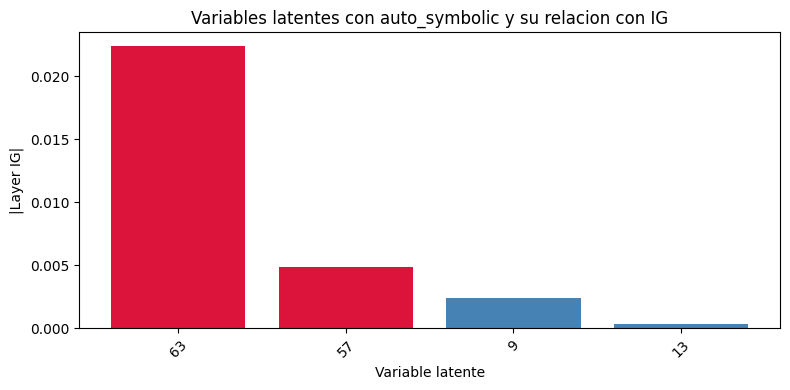

Formula simbolica (KAN clonada con auto_symbolic focalizado):
([0.381651814697394*exp(-0.264700028743377*cos(0.42911958694458*z_13 + 6.79327964782715) - 0.279283371600457*cos(0.442159593105316*z_9 - 5.63439989089966)) + 0.293281078338623*cos(-0.255609450681621*z_9 + 0.791592505740368*sin(0.308639705181122*z_63 + 2.22079992294312) + 8.42537421760078) + 0.264762133359909*cos(0.422929841222867*sin(0.446319580078125*z_13 - 1.04455995559692) - 0.386109350111298*sin(0.433759599924088*z_9 - 4.02288007736206) + 4.65465385832692) + 0.247208821820095 - 0.0803309566476867*exp(-0.203097974423068*z_57) + 0.00152685749344528/(0.0158812830486213*z_9 - 0.202135637326334)**2, 0.00174693367443979*(1.4322311036042*z_57 - 7.23935963533547)**2 + 0.228356212377548*sin(-0.742021966950233*sin(0.446319580078125*z_13 - 1.04455995559692) + 0.677421150040075*sin(0.433759599924088*z_9 - 4.02288007736206) + 6.28361139907207) - 0.01806272380054*cos(-0.74892634828308*z_9 + 2.31933711007741*sin(0.308639705181122*z_63 

In [30]:
# Auto-symbolic focalizado sobre splines de Sproud y relacion con IG
from collections import Counter

AUTO_SYMBOLIC_ENABLED = True
AUTO_SYMBOLIC_ON_TOP_K = min(8, len(sproud_df))
AUTO_SYMBOLIC_R2_THRESHOLD = 0.0
AUTO_SYMBOLIC_WEIGHT_SIMPLE = 0.8
AUTO_SYMBOLIC_VERBOSE = 1
AUTO_SYMBOLIC_TARGET_LAYER = SPROUD_LAYER


def build_clean_kan_clone(source_kan):
    cloned = KAN(
        width=source_kan.width,
        grid=source_kan.grid,
        k=source_kan.k,
        auto_save=False,
        symbolic_enabled=True,
        seed=SEED,
        device=str(DEVICE),
    ).to(DEVICE)
    cloned.load_state_dict(source_kan.state_dict())
    if hasattr(cloned, 'auto_save'):
        cloned.auto_save = False
        # PyKAN >= 0.2.x: usa cloned.get_act(x) para cachear activaciones
    if hasattr(cloned, 'symbolic_enabled'):
        cloned.symbolic_enabled = True
    return cloned


if not AUTO_SYMBOLIC_ENABLED:
    print('AUTO_SYMBOLIC_ENABLED=False. No se ejecuta auto_symbolic.')
else:
    kan_symbolic = build_clean_kan_clone(model.kan)
    if hasattr(kan_symbolic, 'unfix_symbolic_all'):
        try:
            kan_symbolic.unfix_symbolic_all()
        except Exception:
            pass

    selected_edges = sproud_df.head(AUTO_SYMBOLIC_ON_TOP_K).copy()
    selected_pairs = {(int(row.out_idx), int(row.in_idx)) for row in selected_edges.itertuples(index=False)}

    # Restringimos auto_symbolic a los edges seleccionados por Sproud en la capa objetivo.
    layer = AUTO_SYMBOLIC_TARGET_LAYER
    out_dim = kan_symbolic.width_out[layer + 1]
    in_dim = kan_symbolic.width_in[layer]
    for out_idx in range(out_dim):
        for in_idx in range(in_dim):
            if (out_idx, in_idx) not in selected_pairs:
                try:
                    kan_symbolic.act_fun[layer].mask[in_idx][out_idx] = 0
                    kan_symbolic.symbolic_fun[layer].mask[out_idx, in_idx] = 0
                except Exception:
                    pass

    with torch.no_grad():
        _ = kan_symbolic(z_cache.to(DEVICE))

    try:
        kan_symbolic.auto_symbolic(verbose=AUTO_SYMBOLIC_VERBOSE, weight_simple=AUTO_SYMBOLIC_WEIGHT_SIMPLE, r2_threshold=AUTO_SYMBOLIC_R2_THRESHOLD)
        print('auto_symbolic ejecutado correctamente sobre la KAN clonada')
    except Exception as e:
        print('auto_symbolic fallo:', repr(e))

    auto_symbolic_rows = []
    for row in selected_edges.itertuples(index=False):
        out_idx = int(row.out_idx)
        in_idx = int(row.in_idx)
        fun_name = kan_symbolic.symbolic_fun[layer].funs_name[out_idx][in_idx]
        auto_symbolic_rows.append({
            'layer': layer,
            'class_logit': 'BENIGN_LOGIT' if out_idx == 0 else 'MALIGNANT_LOGIT',
            'out_idx': out_idx,
            'in_idx': in_idx,
            'latent_dim': in_idx,
            'importance': float(row.importance),
            'auto_symbolic_fun': fun_name,
        })

    auto_symbolic_df = pd.DataFrame(auto_symbolic_rows)
    display(auto_symbolic_df)

    funs_by_class = (
        auto_symbolic_df
        .groupby(['class_logit', 'auto_symbolic_fun'])
        .size()
        .rename('count')
        .reset_index()
        .sort_values(['class_logit', 'count', 'auto_symbolic_fun'], ascending=[True, False, True])
    )
    display(funs_by_class)

    ig_intersection_df = auto_symbolic_df.merge(
        latent_ig_df[['latent_dim', 'latent_value', 'latent_ig', 'latent_ig_abs', 'sproud_edges_count']],
        on='latent_dim',
        how='left',
    )
    ig_intersection_df['in_top20_ig'] = ig_intersection_df['latent_dim'].isin(top_latent_ig['latent_dim'])
    display(ig_intersection_df.sort_values(['in_top20_ig', 'latent_ig_abs', 'importance'], ascending=[False, False, False]))

    funs_intersection_summary = (
        ig_intersection_df[ig_intersection_df['in_top20_ig']]
        .groupby(['class_logit', 'auto_symbolic_fun'])
        .size()
        .rename('count_in_ig_intersection')
        .reset_index()
        .sort_values(['class_logit', 'count_in_ig_intersection', 'auto_symbolic_fun'], ascending=[True, False, True])
    )
    display(funs_intersection_summary)

    plt.figure(figsize=(8, 4))
    plot_df = ig_intersection_df.sort_values('latent_ig_abs', ascending=False).head(12)
    colors = ['crimson' if x else 'steelblue' for x in plot_df['in_top20_ig']]
    plt.bar(plot_df['latent_dim'].astype(str), plot_df['latent_ig_abs'], color=colors)
    plt.xticks(rotation=45)
    plt.ylabel('|Layer IG|')
    plt.xlabel('Variable latente')
    plt.title('Variables latentes con auto_symbolic y su relacion con IG')
    plt.tight_layout()
    plt.show()

    try:
        auto_symbolic_formula = kan_symbolic.symbolic_formula(var=[f'z_{i}' for i in range(kan_symbolic.width_in[0])])
        print('Formula simbolica (KAN clonada con auto_symbolic focalizado):')
        print(auto_symbolic_formula)
    except Exception as e:
        print('No se pudo extraer symbolic_formula() despues de auto_symbolic:', repr(e))


### Fórmulas simbólicas por clase
Ejecuta la siguiente celda para generar y guardar las fórmulas de BENIGNO y MALIGNO.

In [31]:
# Formulas simbolicas por clase (BENIGNO y MALIGNO)
# Usa la KAN simbolica si existe (kan_symbolic); si no, usa la KAN del modelo principal.

kan_ref = kan_symbolic if 'kan_symbolic' in globals() else model.kan
latent_vars = [f'z_{i}' for i in range(int(kan_ref.width_in[0]))]

try:
    formula_obj = kan_ref.symbolic_formula(var=latent_vars)
except Exception as e:
    raise RuntimeError(f'No se pudo calcular symbolic_formula(): {repr(e)}')

print('=== symbolic_formula() (salida completa) ===')
print(formula_obj)

benign_formula = None
malignant_formula = None

# Intento 1: salida indexable por clase [0]=BENIGNO, [1]=MALIGNO.
if isinstance(formula_obj, (list, tuple)) and len(formula_obj) >= 2:
    benign_formula = formula_obj[0]
    malignant_formula = formula_obj[1]

# Intento 2: salida tipo dict con nombres/indices de clase.
elif isinstance(formula_obj, dict):
    benign_formula = formula_obj.get('BENIGN', formula_obj.get('benign', formula_obj.get(0)))
    malignant_formula = formula_obj.get('MALIGNANT', formula_obj.get('malignant', formula_obj.get(1)))

# Fallback: no se pudo separar programaticamente.
if benign_formula is None or malignant_formula is None:
    print('\nNo fue posible separar automaticamente la formula por clase con el formato devuelto por pykan.')
    print('Revisa la salida completa de symbolic_formula() impresa arriba.')
else:
    print('\n=== Formula simbolica clase BENIGNO (logit 0) ===')
    print(benign_formula)
    print('\n=== Formula simbolica clase MALIGNO (logit 1) ===')
    print(malignant_formula)

# Guardar en archivo para referencia
out_txt = ROOT / 'reports' / 'models' / 'nb08_symbolic_formulas_by_class.txt'
out_txt.parent.mkdir(parents=True, exist_ok=True)
with open(out_txt, 'w', encoding='utf-8') as f:
    f.write('=== symbolic_formula() completa ===\n')
    f.write(str(formula_obj) + '\n\n')
    f.write('=== BENIGNO (logit 0) ===\n')
    f.write(str(benign_formula) + '\n\n')
    f.write('=== MALIGNO (logit 1) ===\n')
    f.write(str(malignant_formula) + '\n')

print('\nGuardado en:', out_txt)

=== symbolic_formula() (salida completa) ===
([0.381651814697394*exp(-0.264700028743377*cos(0.42911958694458*z_13 + 6.79327964782715) - 0.279283371600457*cos(0.442159593105316*z_9 - 5.63439989089966)) + 0.293281078338623*cos(-0.255609450681621*z_9 + 0.791592505740368*sin(0.308639705181122*z_63 + 2.22079992294312) + 8.42537421760078) + 0.264762133359909*cos(0.422929841222867*sin(0.446319580078125*z_13 - 1.04455995559692) - 0.386109350111298*sin(0.433759599924088*z_9 - 4.02288007736206) + 4.65465385832692) + 0.247208821820095 - 0.0803309566476867*exp(-0.203097974423068*z_57) + 0.00152685749344528/(0.0158812830486213*z_9 - 0.202135637326334)**2, 0.00174693367443979*(1.4322311036042*z_57 - 7.23935963533547)**2 + 0.228356212377548*sin(-0.742021966950233*sin(0.446319580078125*z_13 - 1.04455995559692) + 0.677421150040075*sin(0.433759599924088*z_9 - 4.02288007736206) + 6.28361139907207) - 0.01806272380054*cos(-0.74892634828308*z_9 + 2.31933711007741*sin(0.308639705181122*z_63 + 2.2207999229431